# Test de blancura
La prueba de Box-Pierce-Ljung considera como Hipótesis nula (H0) los
residuos son no correlacionados contra la hipótesis alternativa (H1) los residuos tienen correlación. El estadístico de prueba Q depende de la función de autocorrelación y tiene una distribución asintótica chi-cuadrado.

# Recordar instalar librería

In [1]:
#!pip install darts

# Cargar librerías

In [2]:
import numpy as np
from darts import TimeSeries
from darts.datasets import AirPassengersDataset
from darts.models import ExponentialSmoothing
from statsmodels.stats.diagnostic import acorr_ljungbox
import matplotlib.pyplot as plt

c:\Users\Lenovo\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


<Axes: xlabel='Month'>

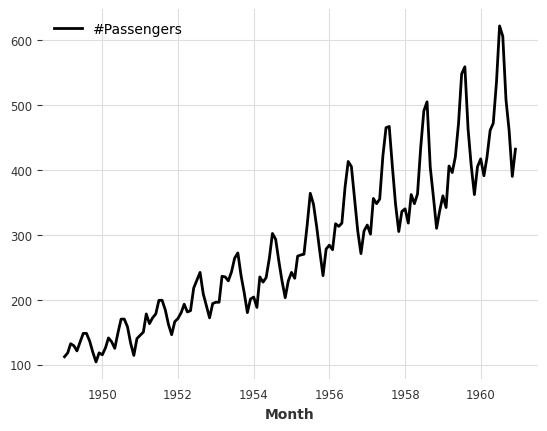

In [3]:
series = AirPassengersDataset().load()
series.plot()

#Aplicar modelo de suavizamiento exponencial
El objetivo es verificar si los residuos son un ruido blanco

<Axes: xlabel='Month'>

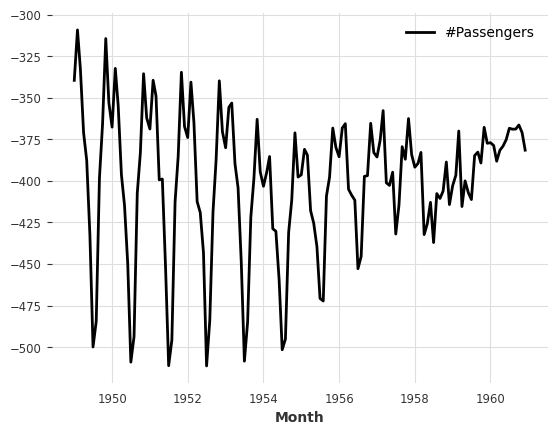

In [4]:
model = ExponentialSmoothing()#Los valores más reciente tienen más peso en el prónostico
model.fit(series)
forecast = model.predict(len(series))
residuals = series - forecast
residuals.plot()

# Test de Box-Pierce-Ljung

El test de blancura aplicado a los residuos muestra que, para los 10 rezagos evaluados, todos los valores p obtenidos son considerablemente inferiores al nivel de significancia del 5 %. Dado que los p-values < 0.05 en todos los rezagos, se rechaza la hipótesis nula de no autocorrelación, lo cual indica que los residuos presentan autocorrelación estadísticamente significativa.

En consecuencia, el modelo no logra capturar por completo la estructura de dependencia temporal de la serie, y los residuos no pueden considerarse ruido blanco. Esto sugiere que el modelo es mejorable y que podrían introducirse términos autorregresivos, de medias móviles o estacionales adicionales.

In [5]:
ljungbox_results = acorr_ljungbox(residuals.values(), lags=10, return_df=True)
print(ljungbox_results)

       lb_stat     lb_pvalue
1    74.993733  4.722106e-18
2    89.870546  3.053929e-20
3    89.927574  2.270457e-19
4   105.034514  8.327964e-22
5   137.820771  5.197677e-28
6   169.369072  6.120788e-34
7   197.006771  4.938830e-39
8   207.130332  2.006087e-40
9   207.187399  1.029505e-39
10  219.764667  1.197186e-41


# Resultados para un ruido blanco

<Axes: xlabel='time'>

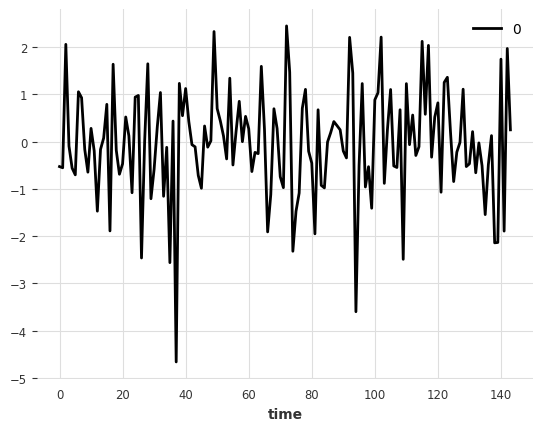

In [6]:
white_noise = TimeSeries.from_values(np.random.randn(144))
white_noise.plot()

In [7]:
ljungbox_white_noise = acorr_ljungbox(white_noise.values(), lags=10, return_df=True)
print(ljungbox_white_noise)

     lb_stat  lb_pvalue
1   1.712587   0.190650
2   3.625961   0.163167
3   3.643453   0.302628
4   5.070843   0.280105
5   5.071490   0.407218
6   6.383256   0.381654
7   6.404069   0.493438
8   6.879263   0.549714
9   6.920390   0.645408
10  7.962343   0.632515


Acá pasa lo contrario, el test de blancura aplicado a los residuos muestra que, para los 10 rezagos evaluados, todos los valores p obtenidos son considerablemente superiores al nivel de significancia del 5 %. Dado que los p-values > 0.05 en todos los rezagos, NO se rechaza la hipótesis nula de no autocorrelación, lo cual indica que los residuos no presentan autocorrelación.

En consecuencia, el modelo captura por completo la estructura de dependencia temporal de la serie, y los residuos pueden considerarse ruido blanco. Esto sugiere que el modelo funciona bastante bien y no se deberían introducir términos autorregresivos.